## Computational Finance Lab Assignment 5
### Estimating Delta (sensitivities) by Monte Carlo
#### Aleksandra Górska, Marcin Pałyga


## Libraries

In [81]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm


sns.set_theme()

## Put and digital options

In [107]:
def BS(S0, r, sigma, T, W):
    return S0*np.exp((r-0.5*sigma**2)*T+sigma*W)

def BS_put_delta(S0, K, r, sigma, T):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return -norm.cdf(-d1)
 
def delta_FD(S0, h, r, sigma, T, K, payoff, W):
    ST_plus = BS(S0+h, r, sigma, T, W)
    ST_minus = BS(S0-h, r, sigma, T, W)
    if payoff == "put":
        G_plus = np.array(list(map(lambda x: max(K-x, 0), ST_plus)))
        G_minus = np.array(list(map(lambda x: max(K-x, 0), ST_minus)))
    elif payoff == "digital":
        G_plus = np.array(list(map(lambda x: 1 if x>K else 0, ST_plus)))
        G_minus = np.array(list(map(lambda x: 1 if x>K else 0, ST_minus)))
    deltas = np.exp(-r*T)*(G_plus-G_minus)/(2*h)
    delta_h = np.mean(deltas)
    CI_l = delta_h - 1.96*np.std(deltas)/np.sqrt(len(W))
    CI_h = delta_h + 1.96*np.std(deltas)/np.sqrt(len(W))
    return delta_h, CI_l, CI_h

def delta_malliavin(S0, r, sigma, T, K, payoff, W):
    ST = S0*np.exp((r-0.5*sigma**2)*T+sigma*W)
    if payoff == "put":
        G = np.array(list(map(lambda x: max(K-x, 0), ST)))
    elif payoff == "digital":
        G = np.array(list(map(lambda x: 1 if x>K else 0, ST)))
    deltas = np.exp(-r*T)*G*W/(S0*sigma*T)
    delta_h = np.mean(deltas)
    CI_l = delta_h - 1.96*np.std(deltas)/np.sqrt(len(W))
    CI_h = delta_h + 1.96*np.std(deltas)/np.sqrt(len(W))
    return delta_h, CI_l, CI_h

def delta_diff(S0, r, sigma, T, K, W):
    ST = BS(S0, r, sigma, T, W)
    Gp = np.array(list(map(lambda x: -1 if x<K else 0, ST)))
    deltas = np.exp(-r*T)*Gp*ST/S0
    delta_h = np.mean(deltas)
    CI_l = delta_h - 1.96*np.std(deltas)/np.sqrt(len(W))
    CI_h = delta_h + 1.96*np.std(deltas)/np.sqrt(len(W))
    return delta_h, CI_l, CI_h

### Choice of h for finite difference

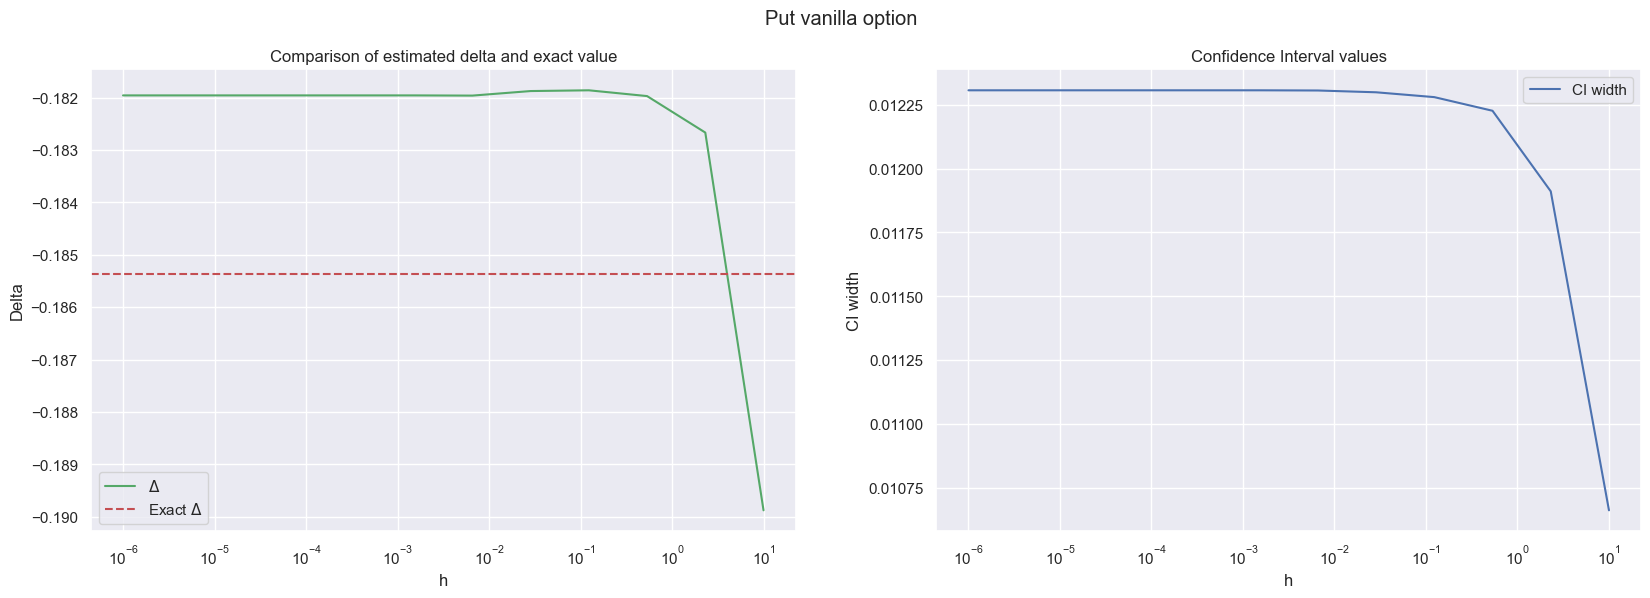

In [105]:
S0 = 100
r = 0.03
sigma = 0.25
T = 1
K = 85
hs = np.logspace(-6, 1, 12)
puts = []
W = np.random.normal(0, np.sqrt(T), 10000)
for h in hs:
    puts.append(delta_FD(S0, h, r, sigma, T, K, "put", W))
puts = np.array(puts)
delta_exact = BS_put_delta(S0, K, r, sigma, T)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
ax1.semilogx(hs, puts[:,0], color='g', label=r"$\Delta$")
ax1.axhline(delta_exact, linestyle="--", color='r', label=r"Exact $\Delta$")
ax1.legend()
ax1.set_xlabel("h")
ax1.set_ylabel("Delta")
ax1.set_title("Comparison of estimated delta and exact value")
ax2.semilogx(hs, puts[:,2]-puts[:,1], label="CI width")
ax2.set_xlabel("h")
ax2.set_ylabel("CI width")
ax2.set_title("Confidence Interval values")
ax2.legend()
plt.suptitle("Put vanilla option")
plt.show()

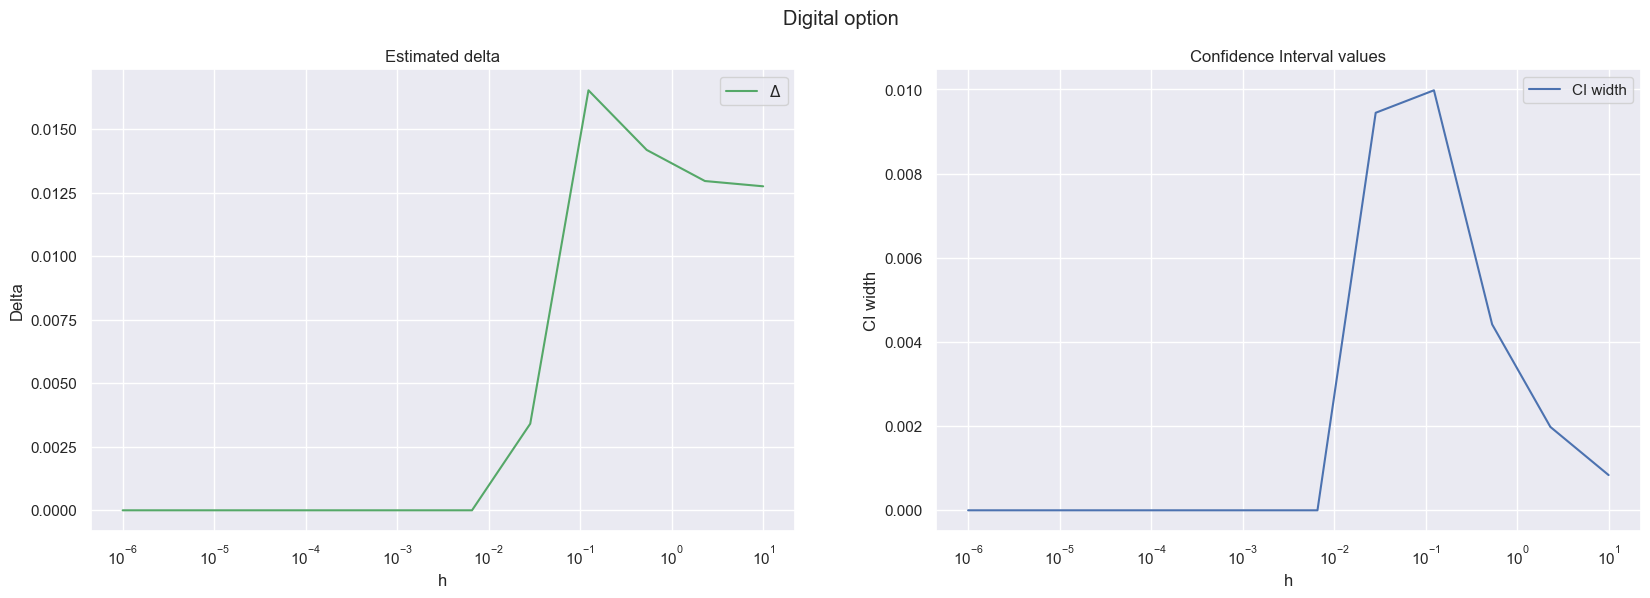

In [ ]:
S0 = 100
r = 0.03
sigma = 0.25
T = 1
K = 85
hs = np.logspace(-6, 1, 12)
digitals = []
W = np.random.normal(0, np.sqrt(T), 10000)
for h in hs:
    digitals.append(delta_FD(S0, h, r, sigma, T, K, "digital", W))
digitals = np.array(digitals)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
ax1.semilogx(hs, digitals[:,0], color='g', label=r"$\Delta$")
ax1.legend()
ax1.set_xlabel("h")
ax1.set_ylabel("Delta")
ax1.set_title("Estimated delta")
ax2.semilogx(hs, digitals[:,2]-digitals[:,1], label="CI width")
ax2.set_xlabel("h")
ax2.set_ylabel("CI width")
ax2.set_title("Confidence Interval values")
ax2.legend()
plt.suptitle("Digital option")
plt.show()

For larger h in vanilla put option becomes smaller because the estimator becomes biased so we should not pick the smallest CI value as our h. For value close to $10^{-1}$ the bias is still negligible and that's the value we pick for other exercises.

### Number of Monte Carlo paths

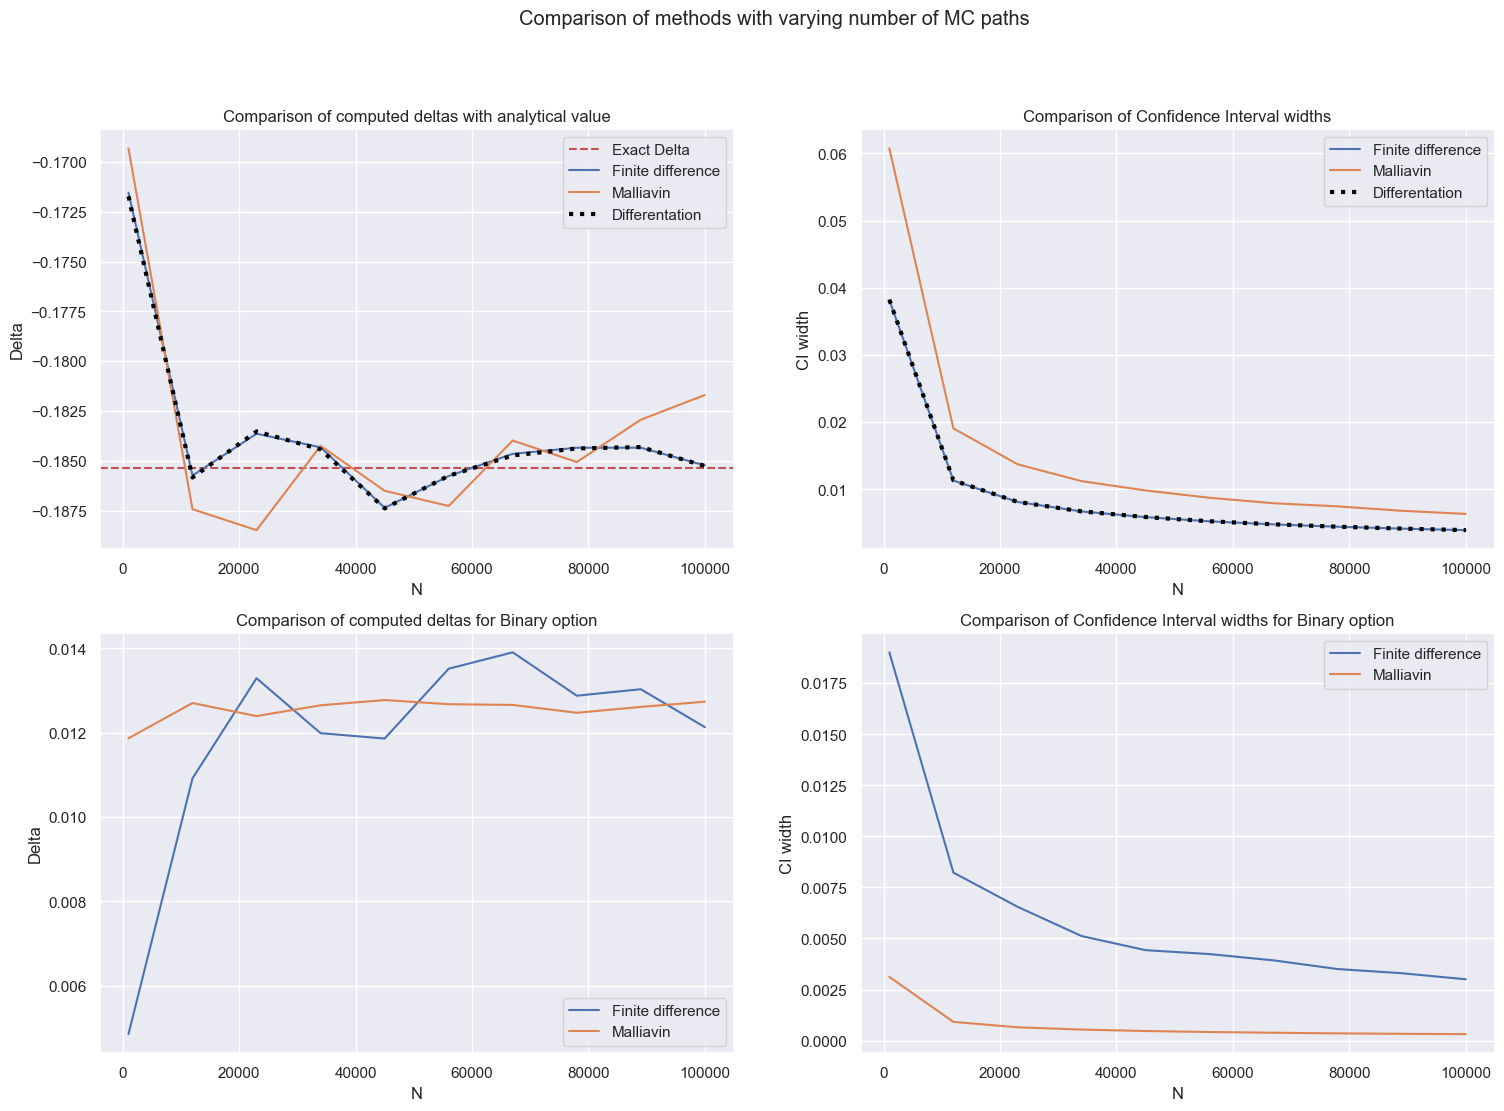

In [139]:
S0 = 100
r = 0.03
sigma = 0.25
T = 1
K = 85
h = 0.1
payoff = "put"
FD = []
malliavin = []
diff = []
Ns = np.linspace(10**3, 10**5, 10)
for N in Ns:
    W = np.random.normal(0, np.sqrt(T), int(N))
    FD.append(delta_FD(S0, h, r, sigma, T, K, payoff, W))
    malliavin.append(delta_malliavin(S0, r, sigma, T, K, payoff, W))
    diff.append(delta_diff(S0, r, sigma, T, K, W))
FD = np.array(FD)
malliavin = np.array(malliavin)
diff = np.array(diff)
delta_exact = BS_put_delta(S0, K, r, sigma, T)
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=(18,12))
ax1.axhline(delta_exact, color='r', linestyle='--', label="Exact Delta")
ax1.plot(Ns, FD[:,0], label="Finite difference")
ax1.plot(Ns, malliavin[:,0], label="Malliavin")
ax1.plot(Ns, diff[:,0], label="Differentation", linestyle=":", linewidth=3, color="black")
ax1.set_xlabel("N")
ax1.set_ylabel("Delta")
ax1.legend()
ax1.set_title("Comparison of computed deltas with analytical value")
ax2.plot(Ns, FD[:,2]-FD[:,1], label="Finite difference")
ax2.plot(Ns, malliavin[:,2]-malliavin[:,1], label="Malliavin")
ax2.plot(Ns, diff[:,2]-diff[:,1], label="Differentation", linestyle=":", linewidth=3, color="black")
ax2.set_xlabel("N")
ax2.set_ylabel("CI width")
ax2.legend()
ax2.set_title("Comparison of Confidence Interval widths")

S0 = 100
r = 0.03
sigma = 0.25
T = 1
K = 85
h = 0.1
payoff = "digital"
FD = []
malliavin = []
Ns = np.linspace(10**3, 10**5, 10)
for N in Ns:
    W = np.random.normal(0, np.sqrt(T), int(N))
    FD.append(delta_FD(S0, h, r, sigma, T, K, payoff, W))
    malliavin.append(delta_malliavin(S0, r, sigma, T, K, payoff, W))
FD = np.array(FD)
malliavin = np.array(malliavin)
ax3.plot(Ns, FD[:,0], label="Finite difference")
ax3.plot(Ns, malliavin[:,0], label="Malliavin")
ax3.set_xlabel("N")
ax3.set_ylabel("Delta")
ax3.legend()
ax3.set_title("Comparison of computed deltas for Binary option")
ax4.plot(Ns, FD[:,2]-FD[:,1], label="Finite difference")
ax4.plot(Ns, malliavin[:,2]-malliavin[:,1], label="Malliavin")
ax4.set_xlabel("N")
ax4.set_ylabel("CI width")
ax4.legend()
ax4.set_title("Comparison of Confidence Interval widths for Binary option")
plt.suptitle("Comparison of methods with varying number of MC paths")
plt.show()

For vanilla put option differentation method best, with Finite Difference method converging to its values with appropriate value selection of h. However Malliavin method is more stable and produces better results for Binary option

### Repetitions

In [ ]:
S0 = 100
r = 0.03
sigma = 0.25
T = 1
K = 85
h = 0.1
payoff = "put"
N = 10000
deltas_FD = []
ci_FD = []
errors_FD = []
coverage_FD = 0
deltas_malliavin = []
ci_malliavin = []
errors_malliavin = []
coverage_malliavin = 0
deltas_diff = []
ci_diff = []
errors_diff = []
coverage_diff = 0
delta_exact = BS_put_delta(S0, K, r, sigma, T)
for i in range(30):
    W = np.random.normal(0, np.sqrt(T), N)
    delta, cl_l, cl_h = delta_FD(S0, h, r, sigma, T, K, payoff, W)
    deltas_FD.append(delta)
    ci_FD.append(cl_h-cl_l)
    errors_FD.append((delta-delta_exact)**2)
    if cl_l <= delta_exact <= cl_h:
        coverage_FD += 1

    delta, cl_l, cl_h = delta_malliavin(S0, r, sigma, T, K, payoff, W)
    deltas_malliavin.append(delta)
    ci_malliavin.append(cl_h-cl_l)
    errors_malliavin.append((delta-delta_exact)**2)
    if cl_l <= delta_exact <= cl_h:
            coverage_malliavin += 1
    delta, cl_l, cl_h = delta_diff(S0, r, sigma, T, K, W)
    deltas_diff.append(delta)
    ci_diff.append(cl_h-cl_l)
    errors_diff.append((delta-delta_exact)**2)
    if cl_l <= delta_exact <= cl_h:
            coverage_diff += 1

#### RMSEs

In [145]:
print(f"Average of Root Mean Squared Errors\n")
print(f"Finite Difference: {np.sqrt(np.mean(errors_FD)):.6f}")
print(f"Malliavin: {np.sqrt(np.mean(errors_malliavin)):.6f}")
print(f"Differentiation: {np.sqrt(np.mean(errors_diff)):.6f}")

Average of Root Mean Squared Errors

Finite Difference: 0.002730
Malliavin: 0.005185
Differentiation: 0.002708


#### CI width

In [147]:
print(f"Average Confidence Interval width\n")
print(f"Finite Difference: {np.mean(ci_FD):.6f}")
print(f"Malliavin: {np.mean(ci_malliavin):.6f}")
print(f"Differentiation: {np.mean(ci_diff):.6f}")

Average Confidence Interval width

Finite Difference: 0.012392
Malliavin: 0.020444
Differentiation: 0.012411


#### Coverage

In [150]:
print(f"Empirical coverage of analytical value of delta using confidence intervals\n")
print(f"Finite Difference: {coverage_FD/30*100:.4f}%")
print(f"Malliavin: {coverage_malliavin/30*100:.4f}%")
print(f"Differentiation: {coverage_diff/30*100:.4f}%")

Empirical coverage of analytical value of delta using confidence intervals

Finite Difference: 100.0000%
Malliavin: 93.3333%
Differentiation: 100.0000%


#### Empirical distributions

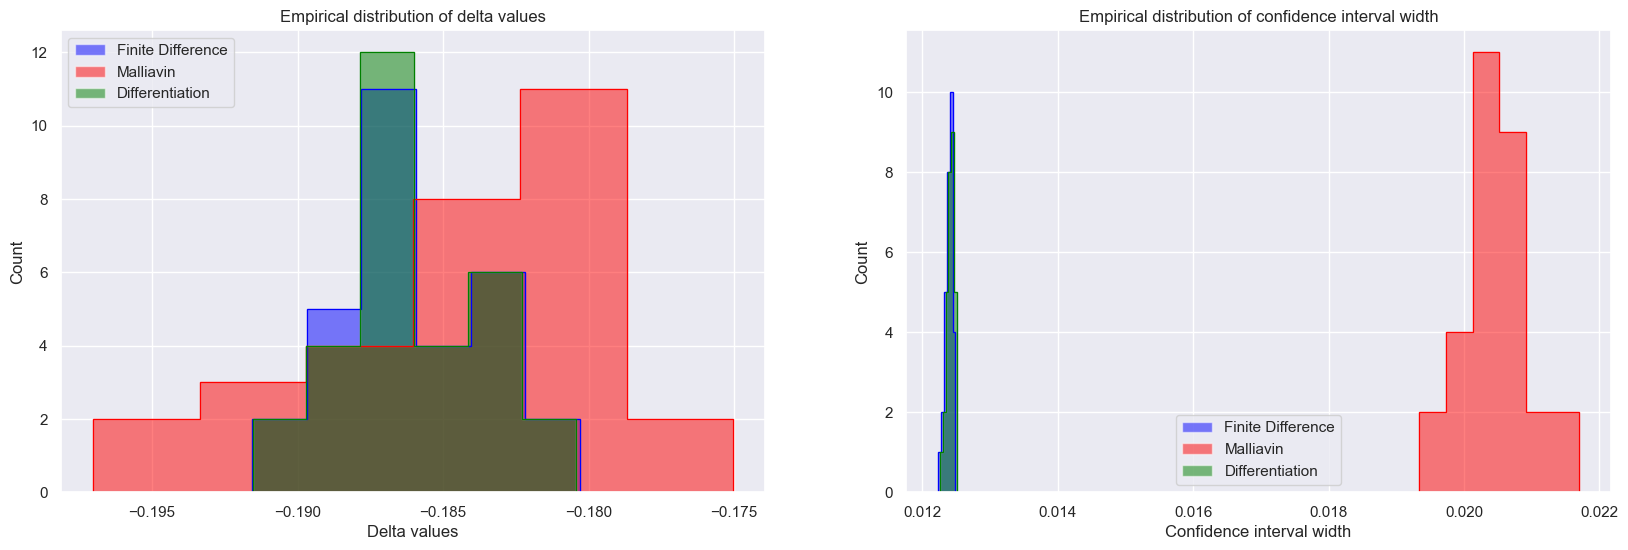

In [166]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(20,6))
ax1.hist(deltas_FD, bins="sqrt", color='blue', alpha=0.5, label="Finite Difference", histtype='stepfilled')
ax1.hist(deltas_FD, bins="sqrt", color='blue', histtype='step')

ax1.hist(deltas_malliavin, bins="sqrt", color="red", alpha=0.5, label="Malliavin", histtype="stepfilled")
ax1.hist(deltas_malliavin, bins="sqrt", color="red", histtype="step")

ax1.hist(deltas_diff, bins="sqrt", color="green", alpha=0.5, label="Differentiation", histtype="stepfilled")
ax1.hist(deltas_diff, bins="sqrt", color="green", histtype="step")
ax1.legend()
ax1.set_xlabel("Delta values")
ax1.set_ylabel("Count")
ax1.set_title("Empirical distribution of delta values")

ax2.hist(ci_FD, bins="sqrt", color='blue', alpha=0.5, label="Finite Difference", histtype='stepfilled')
ax2.hist(ci_FD, bins="sqrt", color='blue', histtype='step')

ax2.hist(ci_malliavin, bins="sqrt", color="red", alpha=0.5, label="Malliavin", histtype="stepfilled")
ax2.hist(ci_malliavin, bins="sqrt", color="red", histtype="step")

ax2.hist(ci_diff, bins="sqrt", color="green", alpha=0.5, label="Differentiation", histtype="stepfilled")
ax2.hist(ci_diff, bins="sqrt", color="green", histtype="step")
ax2.legend()
ax2.set_xlabel("Confidence interval width")
ax2.set_ylabel("Count")
ax2.set_title("Empirical distribution of confidence interval width")
plt.show()


As we can see clearly see on confidence interval width distribution Malliavin method is worse than the other two methods but proofs useful when computing Binary options

## Black-Karasinski short rate model

In [175]:
k=0.8
theta = np.log(0.03)
sigma = 0.03
r0 = 0.03
T = 5
C = 0.04
dt = 1/52

In [ ]:
def disc_factor(rs, t):
    idx = int(t/dt)
    disc = 0
    for i in range(1, idx+1):
        disc += 0.5*(rs[i-1]+rs[i])*dt
    return np.exp(-disc)

def BK_bond(Z, r0):
    ln_r = np.log(r0)
    rs = [r0]
    for z in Z:
        ln_r = ln_r + k*(theta-ln_r)*dt + sigma*np.sqrt(dt)*z
        rs.append(np.exp(ln_r))
    price = disc_factor(rs, T)
    return price

def delta_FD(h, N):
    deltas = []
    for i in range(N):
        Z = np.random.normal(0,1, int(T/dt))
        BK_plus = BK_bond(Z, r0+h)
        BK_minus = BK_bond(Z, r0-h)
        deltas.append((BK_plus-BK_minus)/(2*h))
    return np.array(deltas)

C:\Users\marci\AppData\Local\Temp\ipykernel_7452\3419672945.py:9: RuntimeWarning: invalid value encountered in log
  ln_r = np.log(r0)


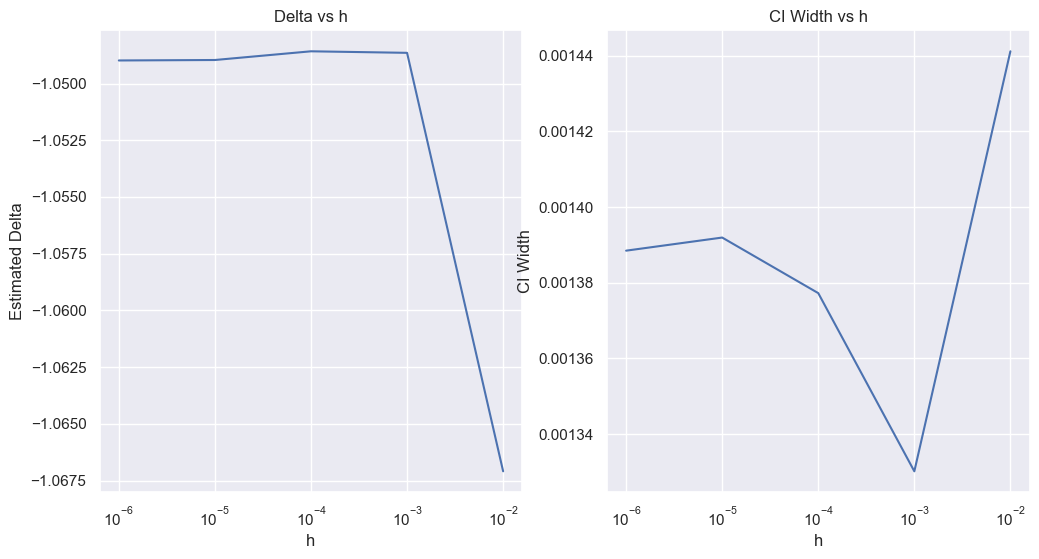

In [ ]:
hs = np.logspace(-6, -1, 6)
mean = []
ci = []
N = 1000
for h in hs:
    deltas = delta_FD(h, N)
    mean.append(np.mean(deltas))
    ci.append(2*1.96*np.std(deltas)/np.sqrt(N))
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,6))
ax1.semilogx(hs, mean)
ax1.set_xlabel('h')
ax1.set_ylabel('Estimated Delta')
ax1.set_title('Delta vs h')
ax2.semilogx(hs, ci)
ax2.set_xlabel('h')
ax2.set_ylabel('CI Width')
ax2.set_title('CI Width vs h')
plt.show()

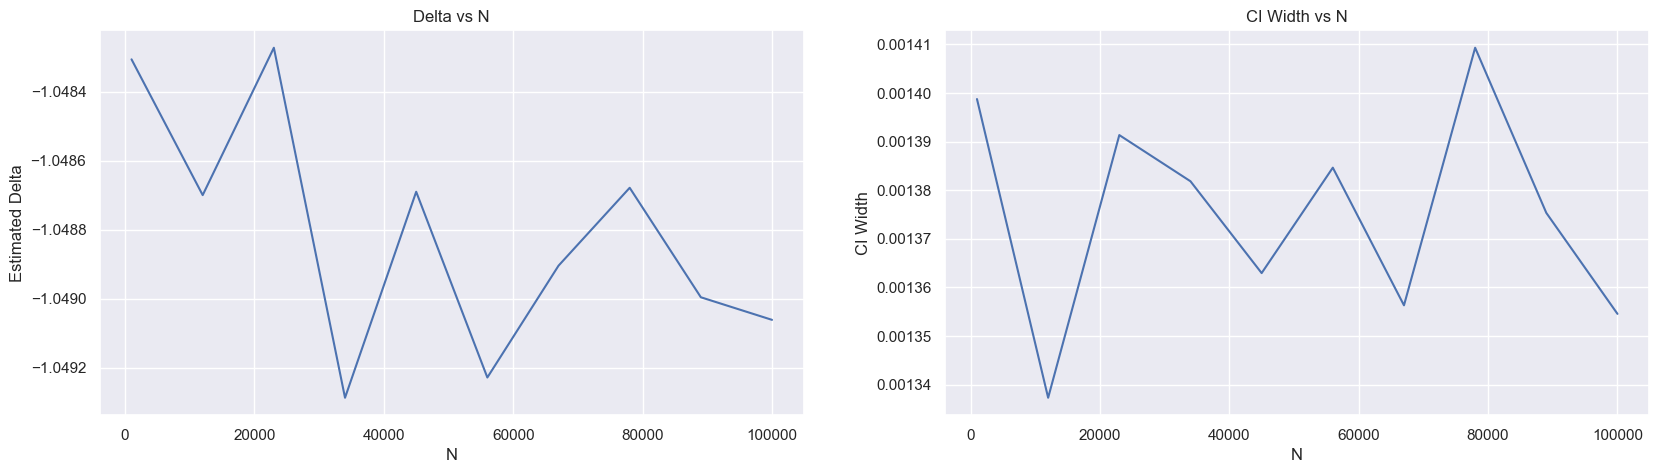

In [200]:
h = 0.001
Ns = np.linspace(10**3, 10**5, 10)
mean = []
ci = []
for n in Ns:
    deltas = delta_FD(h, N)
    mean.append(np.mean(deltas))
    ci.append(2*1.96*np.std(deltas)/np.sqrt(N))
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(20,5))
ax1.plot(Ns, mean)
ax1.set_xlabel('N')
ax1.set_ylabel('Estimated Delta')
ax1.set_title('Delta vs N')
ax2.plot(Ns, ci)
ax2.set_xlabel('N')
ax2.set_ylabel('CI Width')
ax2.set_title('CI Width vs N')
plt.show()

Both Estimated values and confidence interval widths doesn't change much with increasing N

## Greeks

In [ ]:
def delta_FD(S0, h, r, sigma, T, K, payoff, W):
    ST_plus = BS(S0+h, r, sigma, T, W)
    ST_minus = BS(S0-h, r, sigma, T, W)
    if payoff == "put":
        G_plus = np.array(list(map(lambda x: max(K-x, 0), ST_plus)))
        G_minus = np.array(list(map(lambda x: max(K-x, 0), ST_minus)))
    elif payoff == "digital":
        G_plus = np.array(list(map(lambda x: 1 if x>K else 0, ST_plus)))
        G_minus = np.array(list(map(lambda x: 1 if x>K else 0, ST_minus)))
    deltas = np.exp(-r*T)*(G_plus-G_minus)/(2*h)
    delta_h = np.mean(deltas)
    CI_l = delta_h - 1.96*np.std(deltas)/np.sqrt(len(W))
    CI_h = delta_h + 1.96*np.std(deltas)/np.sqrt(len(W))
    return delta_h, CI_l, CI_h

def gamma_FD(S0, h, r, sigma, T, K, payoff, W):
    ST_plus  = BS(S0 + h, r, sigma, T, W)
    ST       = BS(S0,     r, sigma, T, W)
    ST_minus = BS(S0 - h, r, sigma, T, W)
    if payoff == "put":
        G_plus  = np.maximum(K - ST_plus, 0)
        G       = np.maximum(K - ST, 0)
        G_minus = np.maximum(K - ST_minus, 0)
    elif payoff == "digital":
        G_plus  = (ST_plus  > K).astype(float)
        G       = (ST       > K).astype(float)
        G_minus = (ST_minus > K).astype(float)
    gammas = np.exp(-r*T) * (G_plus - 2*G + G_minus) / h**2
    gamma_h = np.mean(gammas)
    CI_l = gamma_h - 1.96*np.std(gammas)/np.sqrt(len(W))
    CI_h = gamma_h + 1.96*np.std(gammas)/np.sqrt(len(W))
    return gamma_h, CI_l, CI_h

def vega_FD(S0, h, r, sigma, T, K, payoff, W):
    ST_plus = BS(S0, r, sigma+h, T, W)
    ST_minus = BS(S0, r, sigma-h, T, W)
    if payoff == "put":
        G_plus = np.array(list(map(lambda x: max(K-x, 0), ST_plus)))
        G_minus = np.array(list(map(lambda x: max(K-x, 0), ST_minus)))
    elif payoff == "digital":
        G_plus = np.array(list(map(lambda x: 1 if x>K else 0, ST_plus)))
        G_minus = np.array(list(map(lambda x: 1 if x>K else 0, ST_minus)))
    vegas = np.exp(-r*T)*(G_plus-G_minus)/(2*h)
    vega_h = np.mean(vegas)
    CI_l = vega_h - 1.96*np.std(deltas)/np.sqrt(len(W))
    CI_h = vega_h + 1.96*np.std(deltas)/np.sqrt(len(W))
    return vega_h, CI_l, CI_h

def rho_FD(S0, h, r, sigma, T, K, payoff, W):
    ST_plus = BS(S0, r+h, sigma, T, W)
    ST_minus = BS(S0, r-h, sigma, T, W)
    if payoff == "put":
        G_plus = np.array(list(map(lambda x: max(K-x, 0), ST_plus)))
        G_minus = np.array(list(map(lambda x: max(K-x, 0), ST_minus)))
    elif payoff == "digital":
        G_plus = np.array(list(map(lambda x: 1 if x>K else 0, ST_plus)))
        G_minus = np.array(list(map(lambda x: 1 if x>K else 0, ST_minus)))
    rhos = (np.exp(-(r + h)*T)*G_plus-np.exp(-(r - h)*T)*G_minus)/(2*h)
    rho_h = np.mean(rhos)
    CI_l = rho_h - 1.96*np.std(deltas)/np.sqrt(len(W))
    CI_h = rho_h + 1.96*np.std(deltas)/np.sqrt(len(W))
    return rho_h, CI_l, CI_h

def theta_FD(S0, h, r, sigma, T, K, payoff, W):
    ST_plus = BS(S0, r, sigma, T, W)
    ST_minus = BS(S0, r, sigma, T-h, W)
    if payoff == "put":
        G_plus = np.array(list(map(lambda x: max(K-x, 0), ST_plus)))
        G_minus = np.array(list(map(lambda x: max(K-x, 0), ST_minus)))
    elif payoff == "digital":
        G_plus = np.array(list(map(lambda x: 1 if x>K else 0, ST_plus)))
        G_minus = np.array(list(map(lambda x: 1 if x>K else 0, ST_minus)))
    thetas = (np.exp(-r*(T-h))*G_minus-np.exp(-r*T)*G_plus)/h
    theta_h = np.mean(thetas)
    CI_l = theta_h - 1.96*np.std(deltas)/np.sqrt(len(W))
    CI_h = theta_h + 1.96*np.std(deltas)/np.sqrt(len(W))
    return theta_h, CI_l, CI_h